# Random Forest


O objetivo do projeto é prever a pontuação dos vinhos usando o algoritmo de Regressão de Random Forest para classificação multiclasse a partir de uma base de dados de avaliações de vinhos.
A base contém algumas características químicas do vinho que influemciam na sua qualidade.

**Caracaterísticas químicas do vinho:**
- Características dos Vinhos (Features)
- Fixed Acidity: Acidez fixa do vinho.
- Volatile Acidity: Acidez volátil do vinho.
- Citric Acid: Quantidade de ácido cítrico no vinho.
- Residual Sugar: Açúcar residual presente no vinho.
- Chlorides: Nível de cloretos no vinho.
- Free Sulfur Dioxide: Dióxido de enxofre livre no vinho.
- Total Sulfur Dioxide: Quantidade total de dióxido de enxofre no vinho.
- Density: Densidade do vinho.
- pH: Nível de pH do vinho.
- Sulphates: Quantidade de sulfatos no vinho.
- Alcohol: Teor alcoólico do vinho.

**Qualidade do Vinho (Variável de Saída,Target):**

Quality: Pontuação do vinho baseada em dados sensoriais, variando de 0 a 10.


In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots

In [2]:
df_original = pd.read_csv("winequality-red.csv", delimiter=',')
df = df_original.copy()
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


# Pré processamento dos dados.

## Verifcação da base 
Todas as variáveis estão no formato adequado, não há dados ausentes ou nulos

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
print(f"\nCampos com valores nulos:\n{df.isnull().sum()}")


Campos com valores nulos:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


# 2 - Realize a segunda e terceita etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.




## Verificação de Outliers
fixed acidity: valor máximo superior ao limite 14

In [5]:
df['fixed acidity'].describe()

count    1599.000000
mean        8.319637
std         1.741096
min         4.600000
25%         7.100000
50%         7.900000
75%         9.200000
max        15.900000
Name: fixed acidity, dtype: float64

In [6]:
df = df[df['fixed acidity'] <= 14]
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000
mean,8.284538,0.528143,0.269510,2.532715,0.087463,15.901948,46.546826,0.996723,3.312872,0.657555,10.421213,5.634821
std,1.673064,0.178907,0.193986,1.405646,0.047178,10.474248,32.937178,0.001858,0.152680,0.169678,1.059742,0.806745
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996720,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997800,3.400000,0.730000,11.100000,6.000000
max,14.000000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.000000,8.000000


mean + 2*std para agilizar a análise
a ideia é que 2var para além da média não deve ser muito distante de 75 nem max, se for, algo estranho está aocntecendo e vale avaliar mais
uma análise um pouco subjetiva, mas para uma avaliação rápida, pode ajudar


as variáveis que me chamarm a atenção foram:
volatlie acidity
residual sugar
clorides
total sulfur dioxide
vamos olhar o histograma de cada um

In [7]:
qtd_base_original = df['quality'].count()
print(qtd_base_original)

1591


In [8]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000
mean,8.284538,0.528143,0.269510,2.532715,0.087463,15.901948,46.546826,0.996723,3.312872,0.657555,10.421213,5.634821
std,1.673064,0.178907,0.193986,1.405646,0.047178,10.474248,32.937178,0.001858,0.152680,0.169678,1.059742,0.806745
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996720,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997800,3.400000,0.730000,11.100000,6.000000
max,14.000000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.000000,8.000000


In [9]:
for campo in df.columns:
    fig = make_subplots(rows=1, cols=2, subplot_titles=[f'Histograma de {campo}', f'Box Plot de {campo}'])
    fig.add_trace(
        px.histogram(df, x=campo, histnorm="percent", nbins=60).data[0],
        row=1, col=1
    )
    fig.add_trace(
        px.box(df, y=campo).data[0],
        row=1, col=2
    )
    fig.update_layout(title_text=f'{campo}', showlegend=False)
    fig.show()
    

In [10]:
campos = ["L Inf","Média", "L Sup", "IQR", "Max"]
df_iqrs = pd.DataFrame(columns=campos)
i = 0
for campo in df:
    IQR = df[campo].mean()+1.5*(df[campo].quantile(0.75)-df[campo].quantile(0.25))
    limite_inferior = df[campo].quantile(0.25) - 1.5 * IQR
    limite_superior = df[campo].quantile(0.75) + 1.5 * IQR
    df_iqrs.loc[campo] = [
        limite_inferior,
        df[campo].mean(),
        limite_superior,
        IQR,
        df[campo].max()
    ]
    i += 1
print(df_iqrs)

                           L Inf      Média       L Sup         IQR        Max
fixed acidity         -10.051807   8.284538   26.351807   11.434538   14.00000
volatile acidity       -0.964714   0.528143    1.994714    0.903143    1.58000
citric acid            -1.056765   0.269510    1.566765    0.764510    1.00000
residual sugar         -3.474073   2.532715    7.974073    3.582715   15.50000
chlorides              -0.106194   0.087463    0.266194    0.117463    0.61100
free sulfur dioxide   -48.352923  15.901948   76.352923   36.901948   72.00000
total sulfur dioxide -137.820239  46.546826  221.820239  106.546826  289.00000
density                -0.504435   0.996723    2.497835    1.000023    1.00369
pH                     -2.186809   3.312872    8.796809    3.597872    4.01000
sulphates              -0.841332   0.657555    2.121332    0.927555    2.00000
alcohol                -9.731820  10.421213   30.331820   12.821213   14.00000
quality                -5.702231   5.634821   16.702

In [11]:
px.bar(df_iqrs[["Max", "L Sup", "Média"]], barmode="overlay", opacity=0.75, title="Distribuição" ).show()

importante destacar que essa comparação não fala da quantidade dos dados, mas o quanto cada um desses valores representa do máximo. isso serve para entendermos em que medida a amostra tem outliers, uma análise prelimnar.
por exemplo, no caso do ph, o limiar geralmente usado para determinar se um valor é outrlier ou nao, o iqr está muito próximo do valor de max. isso indica que os valores superiores a iqr não estão muito fora da curva, sua exclusão não parece obrigatoria.
já no caso do residual sugar, vemos que a distancia entre o maximo medido e o IQR é muito grande, então esse valor está muito fora da curva.


individualmente, os valores não são alto, nenhum supera 10%. porém, se todos forem elminados, a base é reduzida a 1.13% do seu tamanho. 
por esse motivo, vou escolher substituir todos pela sua média, ao invés de elimiar.

os outliers de densidade podem ser resolvidos apenas mudando o arredondamento, dado que a diferença está na casa decimal. supondo que a unidade é g/l  

a base após os dados alterados representa 80% dos dados originais, então tá ok essa limpeza.
densidade e ph não tem necessidade de serem excluidos, apenas arredondados

In [12]:
df['density'] = df['density'].round(3)
df['pH'] = df['pH'].round(1)

In [13]:
for campo in df:
    if campo not in ['density', 'pH', 'quality']:
        df[campo] = df[campo].apply(lambda x: df_iqrs['Média'][campo] if (x < df_iqrs['L Inf'][campo] or x > df_iqrs['L Sup'][campo]) else x)


B) Verifique o balanceamento da váriavel Target.


a variável target de treinamento deve ser balanceada. Ou seja, a distribuição de valores deve ser similar, balanceada, para que o modelo não seja treinado de maneira tendenciosa.
o hist a baixo mostra que os dados são desbalanceados. será então necessário aplicar uma correção dos dados para balancear com smothe

In [14]:
px.bar(df['quality'].value_counts(normalize=True), title="Distribuição da variável Target (Treinamento)", labels={'index': 'Quality', 'value': 'Proporção'}, text_auto='.2%').show()

In [15]:
from imblearn.over_sampling import SMOTE

In [16]:
smote = SMOTE(random_state=42)
df, df['quality'] = smote.fit_resample(df, df['quality'])

In [17]:
px.bar(df['quality'].value_counts(normalize=True), title="Distribuição da variável Target (Treinamento)", labels={'index': 'Quality', 'value': 'Proporção'}, text_auto='.2%').show()

Como é possível verifica rno hist acima, as variáveis agora estão normalizadas.


C)  Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.


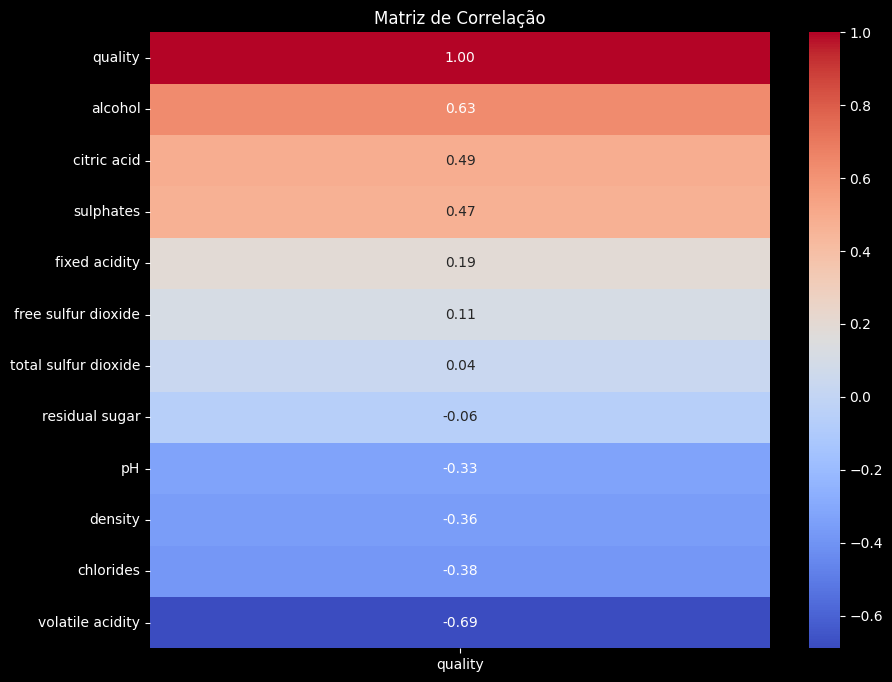

In [18]:
correlation_matrix = df.select_dtypes(include=['number']).corr()
correlation_matrix.sort_values(by='quality', ascending=False, inplace=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix[['quality']], annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

Antes de avalaria as correlaçlões entre as variáveis exploratorias, vou analisra sua relação com a variável targeet.
é possível confirmar que as características que mais influemciam são alcolhol, volatile acidity, sequidas de ácido cítrico, sulfetos . em seguida cloroides, ph e densidade , acidez fixa e dióxido de sulfeto livre, ph. por último, açucar residual, e total de dióxido livre.

para avaliar as demais correlções, vou destacar no mapa apenas as correlações superiores a 0.5
destacam-se
as relações entre medidas de acidez (acidez cítrica, fixa e volátil)
os fulfetos (livre e total)
e densidade e alcol e acidez



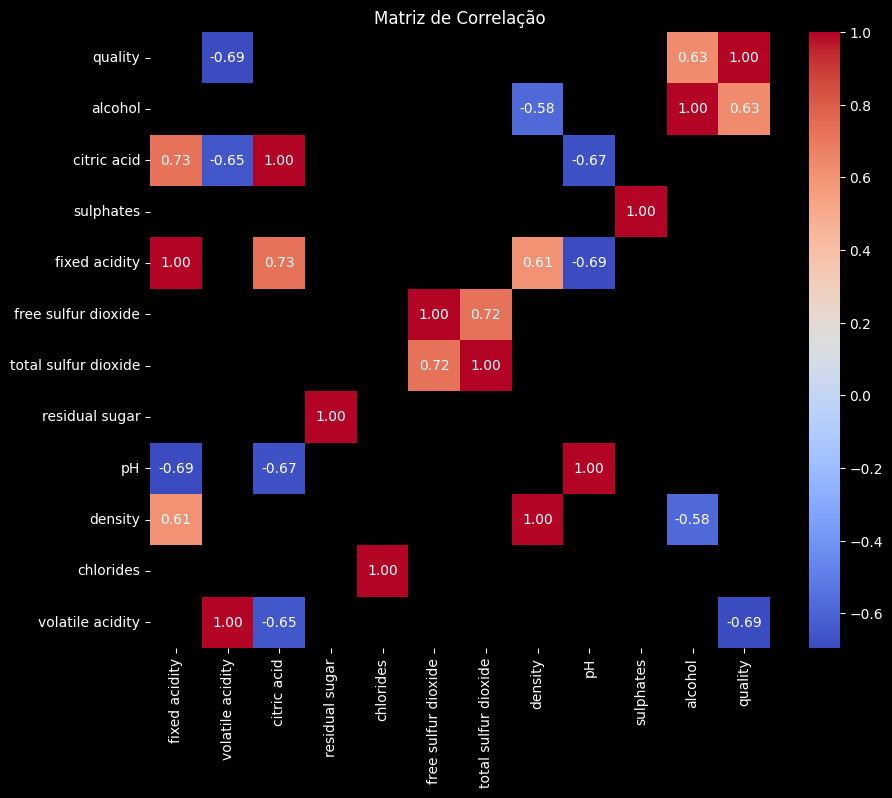

In [19]:
plt.figure(figsize=(10, 8))
correlation_matrix_strong = correlation_matrix[correlation_matrix.abs() > 0.5]
sns.heatmap(correlation_matrix_strong, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()


D) Crie um novo dataframe apenas com as váriaveis que parecem ter maior correlação com a target. (Negativa ou positiva)

In [20]:
df_corr = df[['quality', 'alcohol', 'volatile acidity', 'citric acid', 'sulphates' ]].copy()

# 3 - Preparação Final dos Dados

A) Separe a base em X(Features) e Y(Target)

B) Separe a base em treino e teste.


In [21]:
from sklearn.model_selection import train_test_split

In [23]:
X = df_corr.select_dtypes(include=['int64', 'float64']).drop(columns=['quality'], axis=1)
y = df_corr['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 4 - Modelagem

A) Inicie e treine o modelo de Random Forest


In [24]:
# Treinando o modelo
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)


B) Aplique a base de teste o modelo.


In [32]:
# Fazendo previsões no conjunto de teste
y_pred = rf_model.predict(X_test)

# 5 - Avaliação

A) Avalie as principais métricas da Claissificação e traga insights acerca do resultado, interprete os valores achados.


In [27]:
# Avaliando o modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação:\n", report)
print("Matriz de Confusão:\n", conf_matrix)

Acurácia: 0.78
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.92      0.98      0.95       162
           4       0.81      0.79      0.80       165
           5       0.64      0.71      0.67       168
           6       0.61      0.52      0.56       198
           7       0.75      0.78      0.76       158
           8       0.92      0.95      0.94       165

    accuracy                           0.78      1016
   macro avg       0.78      0.79      0.78      1016
weighted avg       0.77      0.78      0.77      1016

Matriz de Confusão:
 [[158   2   2   0   0   0]
 [  6 130  15  13   1   0]
 [  4  15 119  27   2   1]
 [  3  10  46 102  30   7]
 [  0   3   3  24 123   5]
 [  0   0   0   0   8 157]]


#### Precisão 

Para as classes de qualidade 3 e 8, as maiores, 92% das previsões positivas foram corretas. Para qualidade 7 e 4 81% e 75%, respectivamente, das previsões positivas foram corretas. Para 5 e 6 apenas 64% e 61%, respectivamente, das previsões foram corretas.

#### Recall

Recall indica o percentual dos casos reais e positivos identificados corretamente. Enquanto a precisão avalia o percentual das previsões positivas que estão corretas (100% equivale a todas as previsões em relação a elas mesmas), o recall mede em relação aos positivos reais (100% são todos os casos positivos reais). Ou seja, a precisão mede o percentual do medido que está correto (para previsões positivas), já o recall mede o percentual dos casos reais positivos corretamente previstos.

O recall calculado para cada classe apresenta um padrão similar ao da precisão, seguindo a ordem decrescente das classes 3, 8, 4, 7, 5 e 6. Para as quatro primeiras classes, interpreto que não só as medidas foram precisas, como também a maioria dos casos positivos foram corretamente medidos.

O valor  apresenta um comportamento diferente para as classses 6 e 7. Apesar de ambas terem uma precisão similar, o recall da classe 5 se aproxima das demais classses, enquanto a da classe 6 é bem inferior, quase inferior a 50%. 

#### F1-Score

F1-Score é a média harmónica da precisão e do recall, indicando um resultado que balanceia ambas as medidas.
Como é de se esperar, o resultado reforçou a pior performace nas previsões das classes 5 e 6, especialmente dessa última.

#### Discussão

Ambas as classes são aquelas com maior concentração de dados antes do balanceamento.  O balanceamento aumentou a concentração das outras classes no banco por meio da repetição dos dados. Isso siginfica que o treinamento para essas classes foi mais repetitivo. Já para as classes 5 e 6, os valores permaneceram com sua distribuição original.
Uma segunda hipóstese para esses resultados pode estar em outras etapas do tratamento de dados, como no tratamento de outliners. Como discutido, muitos valores fora da curva foram identificados e transformados para suas médias. Essa alteração pode ter afetado majoritariamente as classes com maior concentração. Uma forma de investigar o caso seria balancear o banco antes do tratamento e aí então avaliar os outliers. Outros problemas poderiam aparecer dessa estratégia, o que precisa ser devidamente ponderado.  

# 5 - Melhorando os Hyperparametros

A) Defina o Grid de parametros que você quer testar

B) Inicie e Treine um novo modelo utilizando o random search.

C) Avalie os resultados do modelo.

D) Você identificou melhorias no modelo após aplicar o random search? Justifique.


ps. Essa parte da atividade demorará um pouco para rodar!

In [ ]:
#seu código aqui

# 6 - Chegando a perfeição

Baseado em tudo que você já aprendeu até agora, quais outras técnicas você acredita que poderiam ser aplicadas ao modelo para melhorar ainda mais suas previsões?